# 📘Домашнє завдання №13 Bagging

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW13

## 📌 Завдання 1  
Використайте датасет Titanic:  
https://www.kaggle.com/datasets/yasserh/titanic-dataset  

- Завантажте дані  
- Проведіть базовий аналіз (огляд колонок, типів, пропусків)  
- Обробіть пропущені значення  
- Закодуйте категоріальні змінні через OneHotEncoding (наприклад, `Sex`, `Embarked`)  

---

## 📌 Завдання 2  
Побудуйте модель класифікації:

- Натренуйте **`RandomForestClassifier`**  
- Зробіть прогноз на тестових даних  
- Обчисліть метрики:
  - accuracy  
  - precision  
  - recall  
  - F1-score  

👉 Проаналізуйте:
- чи є переобучення  
- які метрики найважливіші в цій задачі  

---

## 📌 Завдання 3  
Аналіз важливості ознак:

- Отримайте `feature_importances_`  
- Побудуйте графік важливості ознак  

👉 Проаналізуйте:
- які ознаки найважливіші  
- чи співпадає це з інтуїцією (наприклад, `Sex`, `Pclass`, `Age`)

---

## 📌 Завдання 4  
Використайте датасет Fish Market:  
https://www.kaggle.com/datasets/vipullrathod/fish-market  

- Побудуйте модель **`RandomForestRegressor`**  
- Натренуйте модель для прогнозування (наприклад, `Weight`)  
- Обчисліть метрики:
  - MSE  
  - RMSE  
  - R²  

👉 Проаналізуйте якість моделі  

---

## 📌 Завдання 5  
Тюнінг Random Forest:

- Використайте **`GridSearchCV`** або **`RandomizedSearchCV`**  
- Підберіть гіперпараметри:
  - `n_estimators`  
  - `max_depth`  
  - `min_samples_leaf`  
  - `max_features`  

- Знайдіть найкращу модель  
- Порівняйте метрики з результатами з **Завдання 4**  

👉 Зробіть висновок:
- чи покращилась модель після тюнінгу  
- які параметри найбільше вплинули  


In [1]:
# Synchronization with remote source

import shutil
from operator import invert
from pathlib import Path

# Input data
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW13.git"
main_file_name = "Bohdan_Pinchuk_DS_HW13.ipynb"

# Solution

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_13/temp'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 110 (delta 59), reused 89 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 2.81 MiB | 11.59 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [2]:
## Downloading data

# !pip install kagglehub[pandas-datasets]
# !pip install ipywidgets
# !pip install --upgrade nbformat
# !pip install jinja2

import apps.main as mn

# Input data
db_file_name = "store_hw13.db"

# Solution
titanic_dataset = mn.download_and_extract_from_kagglehub("yasserh/titanic-dataset", "Titanic-Dataset.csv", db_file_name)
fish_market = mn.download_and_extract_from_kagglehub("vipullrathod/fish-market", "Fish.csv", db_file_name)

# Print result
# display(titanic_dataset, fish_market)


## ✅ Рішення 1
Використайте датасет Titanic:
- Завантажте дані
- Проведіть базовий аналіз (огляд колонок, типів, пропусків)
- Обробіть пропущені значення
- Закодуйте категоріальні змінні через OneHotEncoding (наприклад, `Sex`, `Embarked`)

In [3]:
# Data analysis

import numpy as np
import pandas as pd
import apps.reporter as rpt

# Input data
data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(data_set)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,12
Кількість числових ознак,7
Кількість категоріальних ознак,5
Пропущені значення,є


,count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# Data cleaning and filling

import numpy as np
import pandas as pd
import apps.reporter as rpt

# Input data
ages_col_name = "Age"
fares_col_name = "Fare"
sibsp_col_name = "SibSp"
parch_col_name = "Parch"
family_col_name = "Family"
fill_col_list = ["Age", "Embarked"]
drop_col_list = ["PassengerId", "Name", "Ticket", "Cabin"]

# Solution
titanic_dataset.drop(columns=drop_col_list, inplace=True)

# Заповнення пропусків
for col_name in fill_col_list:
    most_often_value = titanic_dataset[col_name].mode()[0]
    titanic_dataset[col_name] = titanic_dataset[col_name].fillna(most_often_value)

# Корегування даних
titanic_dataset[ages_col_name] = titanic_dataset[ages_col_name].round().astype(int)
titanic_dataset[fares_col_name] = titanic_dataset[fares_col_name].round(2).astype(float)

# Заміна даних і очищення
titanic_dataset[family_col_name] = titanic_dataset.apply(
    lambda df_row: df_row[sibsp_col_name] + df_row[parch_col_name] + 1, axis=1)
titanic_dataset.drop(columns=[sibsp_col_name, parch_col_name], inplace=True)

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці після обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(data_set)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,7
Кількість числових ознак,5
Кількість категоріальних ознак,2
Пропущені значення,немає


,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22,7.25,S,2
1,1,1,female,38,71.28,C,2
2,1,3,female,26,7.92,S,1
3,1,1,female,35,53.10,S,2
4,0,3,male,35,8.05,S,1
...,...,...,...,...,...,...,...
886,0,2,male,27,13.00,S,1
887,1,1,female,19,30.00,S,1
888,0,3,female,24,23.45,S,4
889,1,1,male,26,30.00,C,1


In [5]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Input data
cat_col_list = ["Sex", "Embarked"]
# ord_col_list = ["Pclass"]
pd.options.display.float_format = '{:g}'.format
# ord_sort_list = (titanic_dataset[ord_col_list].
#                  drop_duplicates().
#                  sort_values(by=ord_col_list, ascending=True).
#                  values.flatten().tolist())

# Solution
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_col_list),
    # ("ord", OrdinalEncoder(categories=[ord_sort_list]), ord_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

transformed_data = preprocessor.fit_transform(titanic_dataset)
titanic_dataset = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці після кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(columns_df.style.set_caption("Назви колонок").hide(axis='index'))
display(types_df.style.set_caption("Типи даних"))
display(data_set)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,10
Кількість числових ознак,10
Кількість категоріальних ознак,0
Пропущені значення,немає


Columns
Sex_female
Sex_male
Embarked_C
Embarked_Q
Embarked_S
Survived
Pclass
Age
Fare
Family


,Types
Sex_female,float64
Sex_male,float64
Embarked_C,float64
Embarked_Q,float64
Embarked_S,float64
Survived,float64
Pclass,float64
Age,float64
Fare,float64
Family,float64


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Survived,Pclass,Age,Fare,Family
0,0,1,0,0,1,0,3,22,7.25,2
1,1,0,1,0,0,1,1,38,71.28,2
2,1,0,0,0,1,1,3,26,7.92,1
3,1,0,0,0,1,1,1,35,53.1,2
4,0,1,0,0,1,0,3,35,8.05,1
...,...,...,...,...,...,...,...,...,...,...
886,0,1,0,0,1,0,2,27,13,1
887,1,0,0,0,1,1,1,19,30,1
888,1,0,0,0,1,0,3,24,23.45,4
889,0,1,1,0,0,1,1,26,30,1


## ✅ Рішення 2
Побудуйте модель класифікації:

- Натренуйте **`RandomForestClassifier`**
- Зробіть прогноз на тестових даних
- Обчисліть метрики:
  - accuracy
  - precision
  - recall
  - F1-score

👉 Проаналізуйте:
- чи є перенавчання
- які метрики найважливіші в цій задачі

In [6]:
import gc
import pandas as pd
from sklearn.model_selection import train_test_split

# Input data
target_value = "Survived"
test_ratio = 0.2
rng_seed = 42

# Solution
X_data = titanic_dataset.drop(columns=[target_value])
Y_data = titanic_dataset[target_value]

del titanic_dataset

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=test_ratio,
                                                    stratify=Y_data, random_state=rng_seed, shuffle=True)

# Print results
display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для тестування"))

# Clean
_ = gc.collect()

,count,proportion
Survived,,
0,439,0.616573
1,273,0.383427


,count,proportion
Survived,,
0,110,0.614525
1,69,0.385475


**Bagging**

In [7]:
import joblib
import apps.main as mn
from pathlib import Path
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_b.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
mn.calc_class_metrics(Y_test, Y_pred)
print(classification_report(Y_test, Y_pred))

Attribute,Result
Confusion Matrix,[[97 13] [18 51]]
Accuracy (Точність),0.8268
Precision (Влучність),0.7969
Recall (Повнота),0.7391
F1-score,0.7669


              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       110
         1.0       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



**Random Forest**

In [8]:
import joblib
import apps.main as mn
from pathlib import Path
from IPython.core.display import Markdown
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
display(Markdown("**Тренувальні дані:**"))
mn.calc_class_metrics(Y_test, Y_pred)
print(classification_report(Y_test, Y_pred))
display(Markdown("---"))
display(Markdown("**Тестові дані:**"))
mn.calc_class_metrics(Y_train, Y_pred_orig)
print(classification_report(Y_train, Y_pred_orig))

**Тренувальні дані:**

Attribute,Result
Confusion Matrix,[[98 12] [21 48]]
Accuracy (Точність),0.8156
Precision (Влучність),0.8000
Recall (Повнота),0.6957
F1-score,0.7442


              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86       110
         1.0       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



---

**Тестові дані:**

Attribute,Result
Confusion Matrix,[[437 2] [ 11 262]]
Accuracy (Точність),0.9817
Precision (Влучність),0.9924
Recall (Повнота),0.9597
F1-score,0.9758


              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       439
         1.0       0.99      0.96      0.98       273

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [9]:
import joblib
import apps.main as mn
from pathlib import Path
from IPython.core.display import Markdown
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_d5.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
display(Markdown("**Тренувальні дані:**"))
mn.calc_class_metrics(Y_test, Y_pred)
print(classification_report(Y_test, Y_pred))
display(Markdown("---"))
display(Markdown("**Тестові дані:**"))
mn.calc_class_metrics(Y_train, Y_pred_orig)
print(classification_report(Y_train, Y_pred_orig))

**Тренувальні дані:**

Attribute,Result
Confusion Matrix,[[103 7] [ 26 43]]
Accuracy (Точність),0.8156
Precision (Влучність),0.8600
Recall (Повнота),0.6232
F1-score,0.7227


              precision    recall  f1-score   support

         0.0       0.80      0.94      0.86       110
         1.0       0.86      0.62      0.72        69

    accuracy                           0.82       179
   macro avg       0.83      0.78      0.79       179
weighted avg       0.82      0.82      0.81       179



---

**Тестові дані:**

Attribute,Result
Confusion Matrix,[[411 28] [ 77 196]]
Accuracy (Точність),0.8525
Precision (Влучність),0.8750
Recall (Повнота),0.7179
F1-score,0.7887


              precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       439
         1.0       0.88      0.72      0.79       273

    accuracy                           0.85       712
   macro avg       0.86      0.83      0.84       712
weighted avg       0.85      0.85      0.85       712



Із документації для "Confusion Matrix":

Колонка 1 | Колонка 2
--- | ---
true negatives :math:`C_{0,0}` | false positives :math:`C_{0,1}`
false negatives :math:`C_{1,0}` | true positives :math:`C_{1,1}`

Матриця:

№1 | №2
--|--
TN | FP
FN | TP

* TN — фактично/реально 0, передбачено/вгадано 0; (Правильно вказана смерть)
* FP — фактично/реально 0, передбачено/вгадано 1; (Хибна надія на виживання)
* FN — фактично/реально 1, передбачено/вгадано 0; (Помилково вказана смерть)
* TP — фактично/реально 1, передбачено/вгадано 1; (Правильно сповіщено про те що вижив)

- Accuracy (Точність) `[(TP + TN)/(Total)]`: Загальний відсоток правильних відповідей.
- Precision (Влучність) `[TP/(TP + FP)]`: Наскільки ми можемо довіряти моделі, коли вона каже "вижив".
- Recall (Повнота) `[TP/(TP + FN)]`: Який відсоток усіх, хто вижив, ми реально знайшли.

Висновок. Для аналізу чи модель перенавчилася, проведено аналіз прогнозування на тренувальних даних. Тренувальні дані значно більші від тестових, що свідчить, що модель перенавчилася. Для оцінки моделі може бути найважливішою метрикою є балансом між Precision і Recall. При обмеженні глибини дерева до 5 помітно, що метрики майже однакові, а тобто можна вважати, що модель не перенавчилася. Аналізуючи точність Accuracy і співвідношення значень тих що вижили до померлих, у вибірках, то модель дає хороші значення.

## ✅ Рішення 3
Аналіз важливості ознак:

- Отримайте `feature_importances_`
- Побудуйте графік важливості ознак

👉 Проаналізуйте:
- які ознаки найважливіші
- чи співпадає це з інтуїцією (наприклад, `Sex`, `Pclass`, `Age`)

In [10]:
import pandas as pd

# Input data

# Solution
importances_df = (pd.DataFrame({"feature": X_data.columns, "importance": model.feature_importances_}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df)

,feature,importance
0,Sex_male,0.280121
1,Sex_female,0.2456
2,Fare,0.142774
3,Age,0.117265
4,Pclass,0.114369
5,Family,0.0646369
6,Embarked_S,0.0147569
7,Embarked_C,0.0123732
8,Embarked_Q,0.00810275


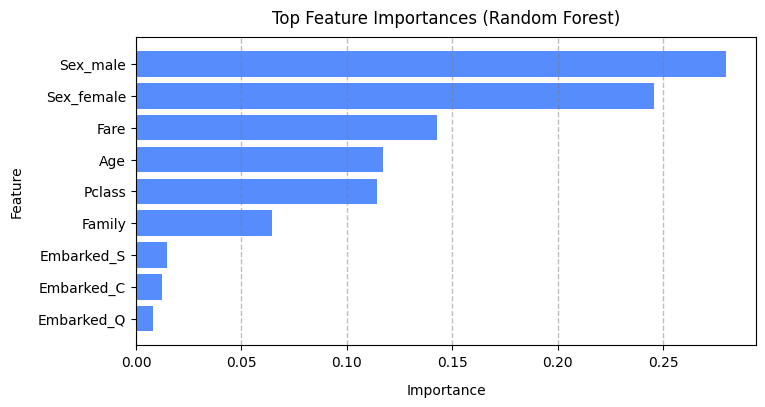

In [11]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(8, 4))

ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()

ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Top Feature Importances (Random Forest)", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

plt.show()

Висновок. Згідно з графіком, найважливішими є перші 6 ознак із найбільшими вагами впливу на результат прогнозування. Так результати співпадають з інтуїцією, ураховуючи те, що Pclass і Fare характеризують фінансовий стан пасажира.

**Grid Search CV**

In [12]:
import apps.main as mn
import apps.reporter as rpt
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GridSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = True
model_file_name = "resources/titanic-dataset_grid.model"
file_path = Path(model_file_name)

accuracy_name = "accuracy"
precision_name = "precision"
recall_name = "recall"
f1_name = "f1"
scorings = {
    'accuracy': accuracy_name,
    'precision': precision_name,
    'recall': recall_name,
    'f1': f1_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = RandomForestClassifier(random_state=rng_seed)
    grid_search = GridSearchCV(grid_model,
                               grid_params,
                               cv=kf,
                               scoring=scorings,
                               refit=f1_name,
                               n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за F1-score", rp.format_value(grid_search.best_score_))

# Print results
mn.calc_class_metrics(Y_test, Y_pred)
rp.print_pd_report(f"Кращі результати (Grid Search)")
print(classification_report(Y_test, Y_pred))

Attribute,Result
Confusion Matrix,[[99 11] [23 46]]
Accuracy (Точність),0.8101
Precision (Влучність),0.8070
Recall (Повнота),0.6667
F1-score,0.7302


Attribute,Result
Найкращі параметри,"{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 100}"
Найкраща оцінка за F1-score,0.7552


              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85       110
         1.0       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



**Randomized Search CV**

In [13]:
import apps.main as mn
import apps.reporter as rpt
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, RandomizedSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = True
model_file_name = "resources/titanic-dataset_rand.model"
file_path = Path(model_file_name)

accuracy_name = "accuracy"
precision_name = "precision"
recall_name = "recall"
f1_name = "f1"
scorings = {
    'accuracy': accuracy_name,
    'precision': precision_name,
    'recall': recall_name,
    'f1': f1_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = RandomForestClassifier(random_state=rng_seed)
    grid_search = RandomizedSearchCV(grid_model,
                                     grid_params,
                                     cv=kf,
                                     n_iter=10,
                                     scoring=scorings,
                                     refit=f1_name,
                                     n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за F1-score", rp.format_value(grid_search.best_score_))

# Print results
mn.calc_class_metrics(Y_test, Y_pred)
rp.print_pd_report(f"Кращі результати (Grid Search)")
print(classification_report(Y_test, Y_pred))

Attribute,Result
Confusion Matrix,[[98 12] [23 46]]
Accuracy (Точність),0.8045
Precision (Влучність),0.7931
Recall (Повнота),0.6667
F1-score,0.7244


Attribute,Result
Найкращі параметри,"{'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': None}"
Найкраща оцінка за F1-score,0.7532


              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85       110
         1.0       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## ✅ Рішення 4
Використайте датасет Fish Market:

- Побудуйте модель **`RandomForestRegressor`**
- Натренуйте модель для прогнозування (наприклад, `Weight`)
- Обчисліть метрики:
  - MSE
  - RMSE
  - R²

👉 Проаналізуйте якість моделі

In [14]:
# Data analysis

import numpy as np
import pandas as pd
import apps.reporter as rpt

# Input data
data_set = fish_market
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(data_set)

Attribute,Result
Кількість рядків,159
Кількість об’єктів у датасеті,159
Кількість стовпців,7
Кількість числових ознак,6
Кількість категоріальних ознак,1
Пропущені значення,немає


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242,23.2,25.4,30,11.52,4.02
1,Bream,290,24,26.3,31.2,12.48,4.3056
2,Bream,340,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363,26.3,29,33.5,12.73,4.4555
4,Bream,430,26.5,29,34,12.444,5.134
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.43,1.269
156,Smelt,12.2,12.1,13,13.8,2.277,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [15]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from sklearn.preprocessing import OneHotEncoder

# Input data
cat_col_list = ["Species"]

# Solution
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

transformed_data = preprocessor.fit_transform(fish_market)
fish_market = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

data_set = fish_market
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці після кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(columns_df.style.set_caption("Назви колонок").hide(axis='index'))
display(types_df.style.set_caption("Типи даних"))
display(data_set)

Attribute,Result
Кількість рядків,159
Кількість об’єктів у датасеті,159
Кількість стовпців,13
Кількість числових ознак,13
Кількість категоріальних ознак,0
Пропущені значення,немає


Columns
Species_Bream
Species_Parkki
Species_Perch
Species_Pike
Species_Roach
Species_Smelt
Species_Whitefish
Weight
Length1
Length2


,Types
Species_Bream,float64
Species_Parkki,float64
Species_Perch,float64
Species_Pike,float64
Species_Roach,float64
Species_Smelt,float64
Species_Whitefish,float64
Weight,float64
Length1,float64
Length2,float64


,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish,Weight,Length1,Length2,Length3,Height,Width
0,1,0,0,0,0,0,0,242,23.2,25.4,30,11.52,4.02
1,1,0,0,0,0,0,0,290,24,26.3,31.2,12.48,4.3056
2,1,0,0,0,0,0,0,340,23.9,26.5,31.1,12.3778,4.6961
3,1,0,0,0,0,0,0,363,26.3,29,33.5,12.73,4.4555
4,1,0,0,0,0,0,0,430,26.5,29,34,12.444,5.134
...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,0,0,0,0,0,1,0,12.2,11.5,12.2,13.4,2.0904,1.3936
155,0,0,0,0,0,1,0,13.4,11.7,12.4,13.5,2.43,1.269
156,0,0,0,0,0,1,0,12.2,12.1,13,13.8,2.277,1.2558
157,0,0,0,0,0,1,0,19.7,13.2,14.3,15.2,2.8728,2.0672


In [16]:
import gc
import pandas as pd
from sklearn.model_selection import train_test_split

# Input data
target_value = "Weight"
test_ratio = 0.2
rng_seed = 42

# Solution
X_data = fish_market.drop(columns=[target_value])
Y_data = fish_market[target_value]

del fish_market

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=test_ratio,
                                                    random_state=rng_seed, shuffle=True)

# Print results
display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True)
], axis=1).head(10).style.format_index("{:g}").set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True)
], axis=1).head(10).style.format_index("{:g}").set_caption("Вибірка для тестування"))

# Clean
_ = gc.collect()

,count,proportion
Weight,,
300,6,0.047244
120,5,0.039370
145,4,0.031496
500,3,0.023622
110,3,0.023622
130,3,0.023622
700,3,0.023622
340,2,0.015748
160,2,0.015748


,count,proportion
Weight,,
1000,3,0.093750
270,2,0.062500
150,2,0.062500
700,2,0.062500
500,2,0.062500
78,1,0.031250
13.4,1,0.031250
200,1,0.031250
7,1,0.031250


**Bagging**

In [17]:
import joblib
import apps.main as mn
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/fish-market_b.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
mn.calc_regres_metrics(Y_test, Y_pred)

Attribute,Result
MAE,43.6834
MSE,4362.5165
RMSE,66.0493
R² (коефіцієнт детермінації),0.9693


**Random Forest**

In [18]:
import joblib
import apps.main as mn
from pathlib import Path
from IPython.core.display import Markdown
from sklearn.ensemble import RandomForestRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/fish-market.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
display(Markdown("**Тренувальні дані:**"))
mn.calc_regres_metrics(Y_test, Y_pred)
display(Markdown("---"))
display(Markdown("**Тестові дані:**"))
mn.calc_regres_metrics(Y_train, Y_pred_orig)

**Тренувальні дані:**

Attribute,Result
MAE,44.3450
MSE,4571.3489
RMSE,67.6118
R² (коефіцієнт детермінації),0.9679


---

**Тестові дані:**

Attribute,Result
MAE,13.1647
MSE,407.6378
RMSE,20.1900
R² (коефіцієнт детермінації),0.9967


In [19]:
import joblib
import apps.main as mn
from pathlib import Path
from IPython.core.display import Markdown
from sklearn.ensemble import RandomForestRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/fish-market_d5.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)
    # save model
    joblib.dump(model, model_file_name)

Y_pred = model.predict(X_test)
Y_pred_orig = model.predict(X_train)

# Print results
display(Markdown("**Тренувальні дані:**"))
mn.calc_regres_metrics(Y_test, Y_pred)
display(Markdown("---"))
display(Markdown("**Тестові дані:**"))
mn.calc_regres_metrics(Y_train, Y_pred_orig)

**Тренувальні дані:**

Attribute,Result
MAE,47.8208
MSE,4883.8334
RMSE,69.8844
R² (коефіцієнт детермінації),0.9657


---

**Тестові дані:**

Attribute,Result
MAE,18.8781
MSE,760.7584
RMSE,27.5818
R² (коефіцієнт детермінації),0.9938


In [20]:
import pandas as pd

# Input data

# Solution
importances_df = (pd.DataFrame({"feature": X_data.columns, "importance": model.feature_importances_}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df)

,feature,importance
0,Width,0.696051
1,Length3,0.155317
2,Length2,0.0693775
3,Length1,0.0676773
4,Height,0.00702792
5,Species_Pike,0.00392688
6,Species_Roach,0.000296008
7,Species_Perch,0.00011572
8,Species_Bream,0.000104238
9,Species_Whitefish,9.06405e-05


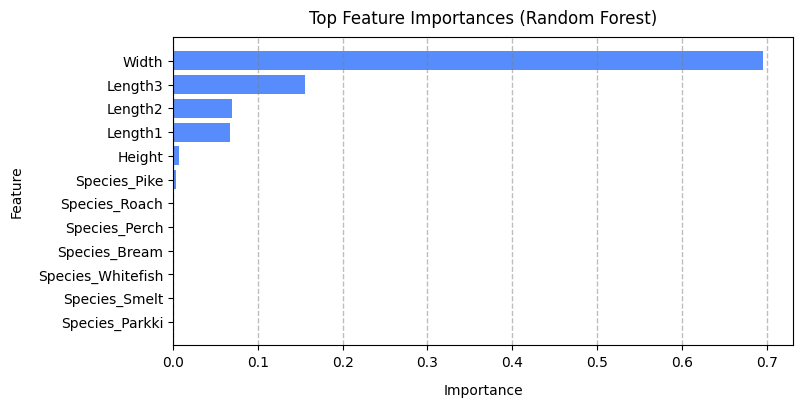

In [21]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(8, 4))

ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()

ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Top Feature Importances (Random Forest)", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

plt.show()

Висновок. Якість прогнозування доволі висока, навіть на тестових даних результати отримані кращі, ніж на навчальних. Графік показує, що найважливішими ознаками є перші 4 із найбільшими вагами впливу на результат прогнозування. А результати враховують фізичну логіку, за якою розміри риби впливають на її вагу та зовсім не впливає назва.

## ✅ Рішення 5
Тюнінг Random Forest:

- Використайте **`GridSearchCV`** або **`RandomizedSearchCV`**
- Підберіть гіперпараметри:
  - `n_estimators`
  - `max_depth`
  - `min_samples_leaf`
  - `max_features`

- Знайдіть найкращу модель
- Порівняйте метрики з результатами з **Завдання 4**

👉 Зробіть висновок:
- чи покращилась модель після тюнінгу
- які параметри найбільше вплинули

**Grid Search CV**

In [22]:
import apps.main as mn
import apps.reporter as rpt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = True
model_file_name = "resources/fish-market_grid.model"
file_path = Path(model_file_name)

mae_name = "neg_mean_absolute_error"
mse_name = "neg_mean_squared_error"
rmse_name = "neg_root_mean_squared_error"
r2_name = "r2"
scorings = {
    'mae': mae_name,
    'mse': mse_name,
    'rmse': rmse_name,
    'r2': r2_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = RandomForestRegressor(random_state=rng_seed)
    grid_search = GridSearchCV(grid_model,
                               grid_params,
                               cv=kf,
                               scoring=scorings,
                               refit=r2_name,
                               n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за R²", rp.format_value(grid_search.best_score_))

# Print results
mn.calc_regres_metrics(Y_test, Y_pred)
rp.print_pd_report(f"Кращі результати (Grid Search)")


Attribute,Result
MAE,42.4995
MSE,4040.4663
RMSE,63.5647
R² (коефіцієнт детермінації),0.9716


Attribute,Result
Найкращі параметри,"{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}"
Найкраща оцінка за R²,0.9598


**Randomized Search CV**

In [23]:
import apps.main as mn
import apps.reporter as rpt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = True
model_file_name = "resources/fish-market_rand.model"
file_path = Path(model_file_name)

mae_name = "neg_mean_absolute_error"
mse_name = "neg_mean_squared_error"
rmse_name = "neg_root_mean_squared_error"
r2_name = "r2"
scorings = {
    'mae': mae_name,
    'mse': mse_name,
    'rmse': rmse_name,
    'r2': r2_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = RandomForestRegressor(random_state=rng_seed)
    grid_search = RandomizedSearchCV(grid_model,
                                     grid_params,
                                     cv=kf,
                                     n_iter=10,
                                     scoring=scorings,
                                     refit=r2_name,
                                     n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    # save model
    joblib.dump(grid_search, model_file_name)

best_grid_model = grid_search.best_estimator_
Y_pred = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за R²", rp.format_value(grid_search.best_score_))

# Print results
mn.calc_regres_metrics(Y_test, Y_pred)
rp.print_pd_report(f"Кращі результати (Randomized Search)")


Attribute,Result
MAE,41.5443
MSE,3741.0739
RMSE,61.1643
R² (коефіцієнт детермінації),0.9737


Attribute,Result
Найкращі параметри,"{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}"
Найкраща оцінка за R²,0.9362


Висновок. Якість прогнозування після перебору параметрів практично не покращилася, а параметри, які зазнали змін, то це максимальна глибина та в регресійному випадку ще й кількість дерев. Моделі для оптимізації гіперпараметрів між собою не мають суттєвої різниці.